# Battery Lab Analytics — SQL + Python
**Electrochemical storage lab (RE04, WHZ Zwickau) · raw Excel → SQLite → SQL metrics → charts**

This notebook is a compact, readable walkthrough of the full pipeline in
[this repo](../README.md). All metrics are computed **in SQL** against
`outputs/battery_lab.db` (built by `src/01_etl.py` from the raw lab workbook);
Python handles orchestration and plotting.

Data-quality issues handled upstream in ETL: German decimal commas, a broken
energy-density formula in the source sheet (recomputed in SQL below), and two
measurement artifacts excluded from the regression fit region.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect("../outputs/battery_lab.db")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print(tables.name.tolist())

['faraday_experiment', 'battery_soc', 'ui_curve', 'cycle_test']


## 1 · Faraday constant from copper electrolysis
Charge transferred $Q = I \cdot t$; Faraday constant $F = \dfrac{Q \cdot M(\mathrm{Cu})}{z \cdot \Delta m}$ with $z=2$, $M=63.55\,$g/mol — computed from both the cathode mass gain and the anode mass loss.

In [2]:
q1 = pd.read_sql('''
WITH params AS (
    SELECT current_a * time_min * 60.0              AS charge_c,
           electrode1_after_g - electrode1_before_g AS dm_cathode_g,
           electrode2_before_g - electrode2_after_g AS dm_anode_g
    FROM faraday_experiment)
SELECT ROUND(charge_c,1) AS charge_C, dm_cathode_g, dm_anode_g,
       ROUND(charge_c*63.55/(2*dm_cathode_g)) AS F_cathode,
       ROUND(charge_c*63.55/(2*dm_anode_g))   AS F_anode,
       ROUND(100*(charge_c*63.55/(2*dm_anode_g)-96485)/96485, 1) AS err_anode_pct
FROM params''', con)
q1

,charge_C,dm_cathode_g,dm_anode_g,F_cathode,F_anode,err_anode_pct
0,1350.0,0.38,0.46,112885.0,93253.0,-3.4


The anode-side value (**93,253 C/mol, −3.4%** vs. literature 96,485) is solid; the
cathode side deviates +17% — copper detaching into solution instead of depositing
cleanly, a known systematic error in this experiment. Reporting the anode value is
the defensible choice.

## 2 · Battery KPIs: state of charge, capacity, energy density
The source sheet's energy-density column contained a **broken formula** for the LiPo
cell (`=M2*G2/I2` referenced header cells). The metric is recomputed from raw columns —
which also validated the three values that were correct.

In [3]:
q2 = pd.read_sql('''
SELECT battery, ROUND(100*soc,1) AS soc_pct, capacity_max_mah,
       ROUND(capacity_current_mah) AS capacity_now_mah,
       ROUND(capacity_current_mah*ocv_measured_v/weight_g, 1) AS energy_density_mwh_g,
       RANK() OVER (ORDER BY capacity_current_mah*ocv_measured_v/weight_g DESC) AS rank
FROM battery_soc ORDER BY rank''', con)
q2

,battery,soc_pct,capacity_max_mah,capacity_now_mah,energy_density_mwh_g,rank
0,LiPo,80.0,980.0,784.0,79.6,1
1,NiMH,88.6,600.0,531.0,53.6,2
2,NiZn,22.0,550.0,121.0,15.5,3
3,Lead-acid,48.0,2500.0,1200.0,12.4,4


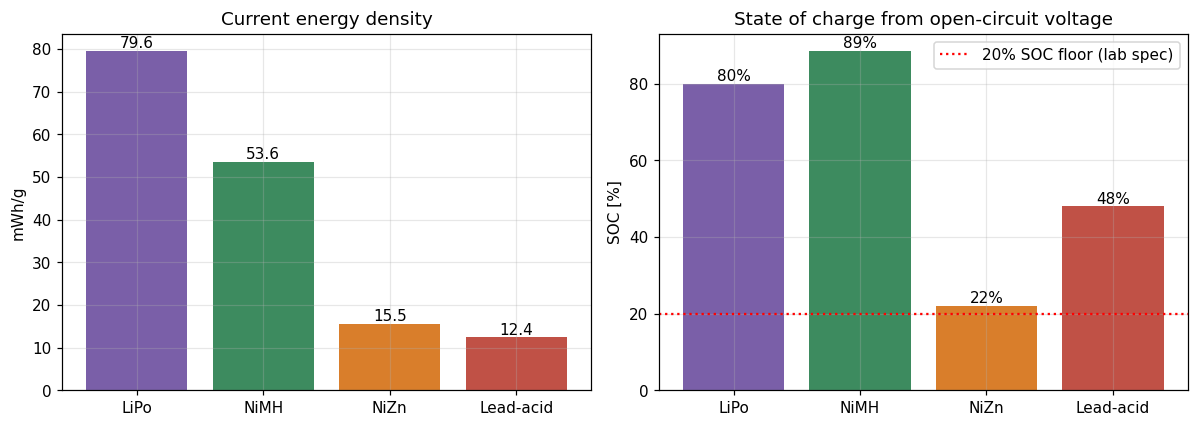

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = {"LiPo": "#7A5FA8", "NiMH": "#3D8B5F", "NiZn": "#D97E2B", "Lead-acid": "#C05146"}
c = [colors[b] for b in q2.battery]
b1 = ax1.bar(q2.battery, q2.energy_density_mwh_g, color=c)
ax1.bar_label(b1, fmt="%.1f"); ax1.set_ylabel("mWh/g")
ax1.set_title("Current energy density")
b2 = ax2.bar(q2.battery, q2.soc_pct, color=c)
ax2.bar_label(b2, fmt="%.0f%%"); ax2.set_ylabel("SOC [%]")
ax2.axhline(20, color="red", ls=":", label="20% SOC floor (lab spec)")
ax2.set_title("State of charge from open-circuit voltage"); ax2.legend()
for ax in (ax1, ax2): ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3 · Internal resistance — least-squares regression in pure SQL
Model: $U = U_0 - R_i \cdot I$, so $R_i = -\text{slope}$. Current is in mA, so the
slope in V/mA is scaled ×1000 to ohms. Two measurement artifacts are excluded from
the fit region with documented `WHERE` clauses: the Li-Ion voltage-rebound point at
1 Ω and the lead-acid points clipped at the 200 mA instrument limit.

In [5]:
q3 = pd.read_sql('''
WITH fit_region AS (
    SELECT battery, current_ma AS x, voltage_v AS y FROM ui_curve
    WHERE NOT (battery='Li-Ion'    AND load_resistance_ohm=1)
      AND NOT (battery='Lead-acid' AND current_ma>=200)),
stats AS (
    SELECT battery, COUNT(*) n, AVG(x) mx, AVG(y) my, AVG(x*y) mxy, AVG(x*x) mxx
    FROM fit_region GROUP BY battery)
SELECT battery, n AS points_used,
       ROUND(-1000.0*(mxy-mx*my)/(mxx-mx*mx), 2) AS internal_resistance_ohm,
       ROUND(my - (mxy-mx*my)/(mxx-mx*mx)*mx, 3) AS u0_intercept_v
FROM stats ORDER BY 3''', con)
q3

,battery,points_used,internal_resistance_ohm,u0_intercept_v
0,Lead-acid,10,0.17,2.062
1,NiMH,12,0.18,1.308
2,Li-Ion,11,0.22,3.963


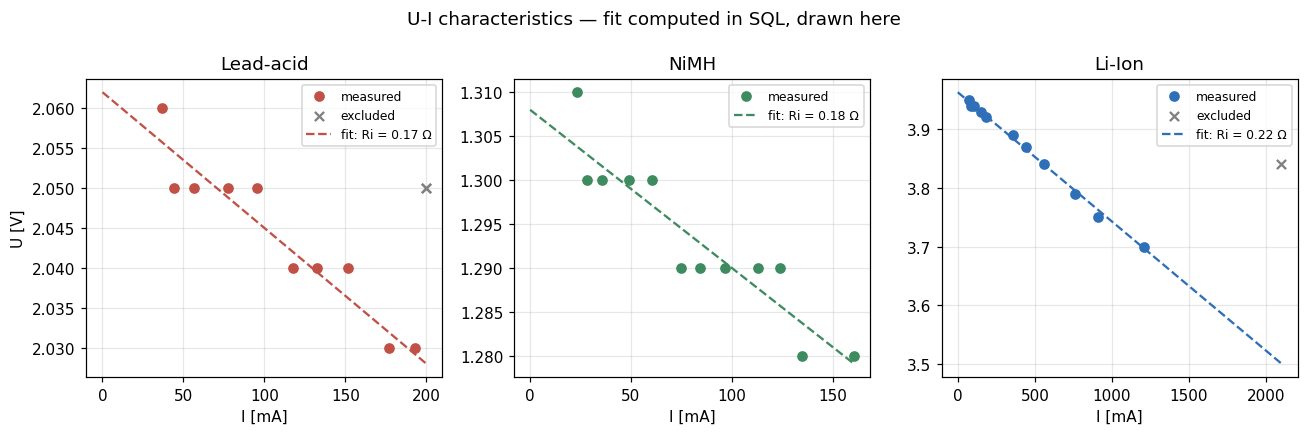

In [6]:
ui = pd.read_sql("SELECT * FROM ui_curve", con)
chem_colors = {"Li-Ion": "#2F6FB7", "NiMH": "#3D8B5F", "Lead-acid": "#C05146"}
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (_, row) in zip(axes, q3.iterrows()):
    grp = ui[ui.battery == row.battery]
    excl = ((grp.battery == "Li-Ion") & (grp.load_resistance_ohm == 1)) | \
           ((grp.battery == "Lead-acid") & (grp.current_ma >= 200))
    color = chem_colors[row.battery]
    ax.scatter(grp[~excl].current_ma, grp[~excl].voltage_v, color=color, zorder=3, label="measured")
    if excl.any():
        ax.scatter(grp[excl].current_ma, grp[excl].voltage_v, marker="x", color="gray",
                   zorder=3, label="excluded")
    xs = np.linspace(0, grp.current_ma.max(), 50)
    ax.plot(xs, row.u0_intercept_v - row.internal_resistance_ohm/1000*xs, "--", color=color,
            label=f"fit: Ri = {row.internal_resistance_ohm:.2f} \u03a9")
    ax.set_title(row.battery); ax.set_xlabel("I [mA]"); ax.grid(alpha=.3); ax.legend(fontsize=8)
axes[0].set_ylabel("U [V]")
plt.suptitle("U-I characteristics — fit computed in SQL, drawn here")
plt.tight_layout(); plt.show()

## 4 · NiMH round-trip energy efficiency
5-minute discharge / 5-minute charge at a constant 230 mA. Energy on each side by
**trapezoidal integration with `LAG()` window functions**:
$W = I \sum \frac{U_i + U_{i-1}}{2}\,\Delta t$, then $\eta = W_\text{dis}/W_\text{chg}$.

In [7]:
q4 = pd.read_sql('''
WITH steps AS (
    SELECT phase, voltage_v, current_ma,
           LAG(voltage_v) OVER (PARTITION BY phase ORDER BY time_s) v_prev,
           time_s - LAG(time_s) OVER (PARTITION BY phase ORDER BY time_s) dt
    FROM cycle_test),
energy AS (
    SELECT phase, SUM((voltage_v+v_prev)/2.0*dt)*MAX(current_ma)/1000.0 AS energy_j
    FROM steps WHERE v_prev IS NOT NULL GROUP BY phase)
SELECT ROUND(MAX(CASE WHEN phase='discharge' THEN energy_j END),2) AS w_discharge_j,
       ROUND(MAX(CASE WHEN phase='charge'    THEN energy_j END),2) AS w_charge_j,
       ROUND(100.0*MAX(CASE WHEN phase='discharge' THEN energy_j END)
                  /MAX(CASE WHEN phase='charge' THEN energy_j END),1) AS voltage_eff_pct
FROM energy''', con)
q4

,w_discharge_j,w_charge_j,voltage_eff_pct
0,86.42,91.18,94.8


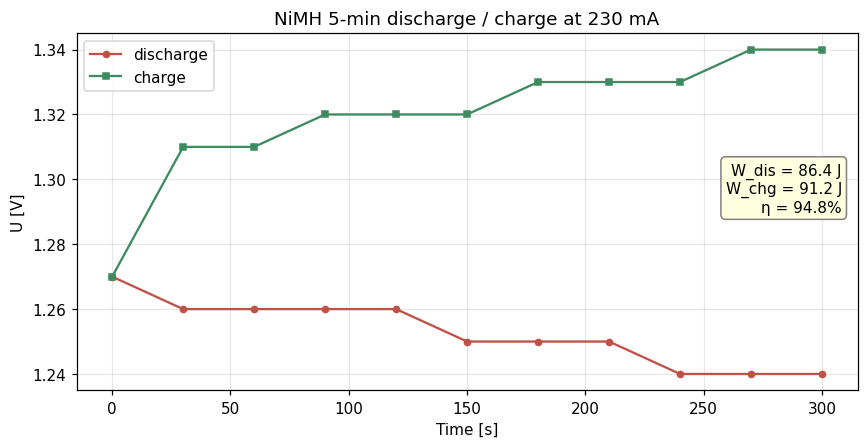

In [8]:
cyc = pd.read_sql("SELECT * FROM cycle_test ORDER BY phase, time_s", con)
fig, ax = plt.subplots(figsize=(8, 4.2))
for phase, style, color in [("discharge", "-o", "#C05146"), ("charge", "-s", "#3D8B5F")]:
    g = cyc[cyc.phase == phase]
    ax.plot(g.time_s, g.voltage_v, style, color=color, ms=4, label=phase)
eff = q4.iloc[0]
ax.annotate(f"W_dis = {eff.w_discharge_j:.1f} J\nW_chg = {eff.w_charge_j:.1f} J\n"
            f"\u03b7 = {eff.voltage_eff_pct:.1f}%",
            xy=(.98, .5), xycoords="axes fraction", ha="right",
            bbox=dict(boxstyle="round", fc="lightyellow", ec="gray"))
ax.set_xlabel("Time [s]"); ax.set_ylabel("U [V]"); ax.grid(alpha=.3); ax.legend()
ax.set_title("NiMH 5-min discharge / charge at 230 mA")
plt.tight_layout(); plt.show()

**94.8% is the *voltage* efficiency of a 5-minute partial cycle** — not the full
round-trip energy efficiency (typically 65–85% for NiMH), which would also include
coulombic losses and end-of-charge inefficiency over a complete cycle. Being explicit
about what a metric does and doesn't capture matters as much as computing it.

---
*Pipeline: `src/01_etl.py` (clean + load) → `sql/analysis_queries.sql` (all metrics) →
`src/03_visualize.py` (figures) · Interactive dashboard: `dashboard/index.html`*